In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

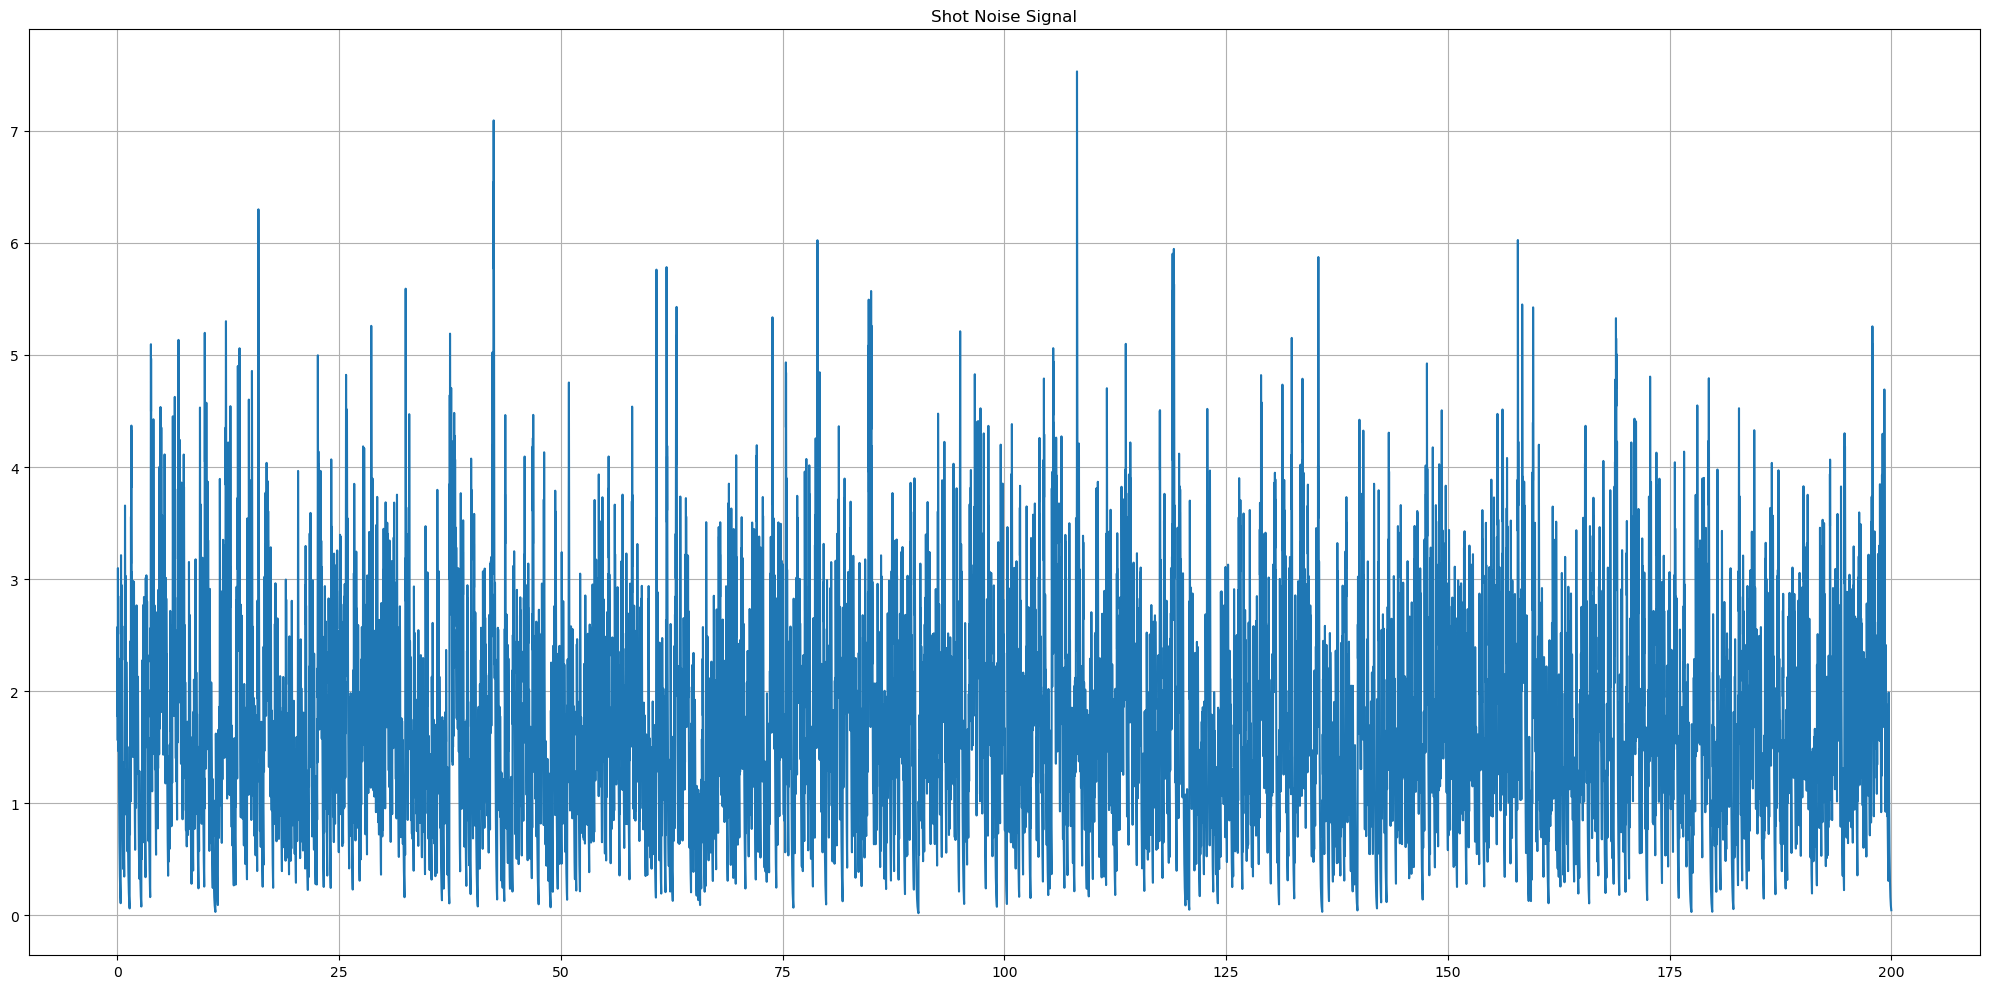

In [8]:
# Parameters
fs = 100        # Sampling frequency (Hz)
T = 200.0          # Duration (seconds)
t = np.arange(0, T, 1/fs)
N = len(t)

# 6. Your original test: Filtered Poisson (Shot Noise)
# Lambda is the rate of events
lam = 20 
poi_events = np.random.poisson(lam / fs, N)
# Exponential kernel
tau = 0.08
kernel = np.exp(-t[:int(fs*0.5)] / tau)
shot_noise = np.convolve(poi_events, kernel, mode='same')

plt.figure(figsize=(20, 10))
plt.plot(t, shot_noise, label='Shot Noise')
plt.title('Shot Noise Signal')
plt.grid(True)

plt.tight_layout()
plt.show()

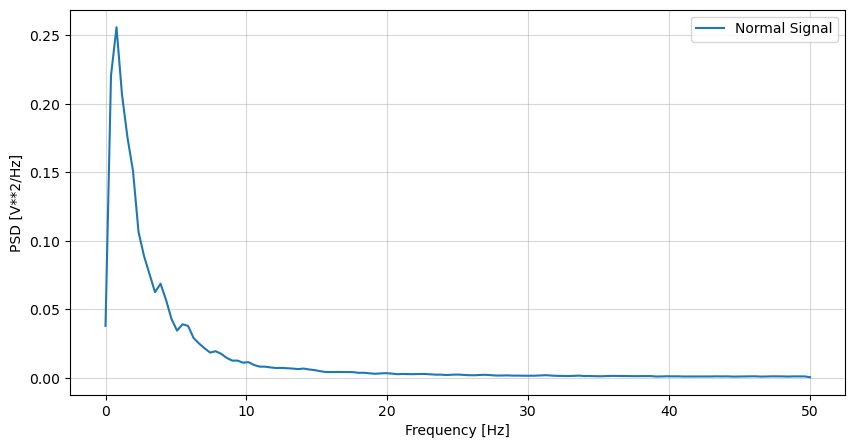

In [9]:
freq, psd = sg.welch(shot_noise, fs=fs)

plt.figure(figsize=(10, 5))
#plt.loglog(frequencies_normal, psd_normal)
#plt.loglog(freq, psd)
plt.plot(freq, psd)
#plt.title('Power Spectral Density')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(['Normal Signal', 'Raw Signal'])
plt.show()


In [10]:
from scipy.optimize import curve_fit

def fit_lorentzian_psd(freq, psd, f_min, f_max):
    def lorentzian(f, A, tau, white_noise):
        return A / (1 + (2 * np.pi * f * tau)**2) + white_noise

    # Create a boolean mask
    mask = (freq >= f_min) & (freq <= f_max)
    f_fit = freq[mask]
    psd_fit = psd[mask]

    # --- 4. Perform Fit on Interval ---
    try:
        p0 = [psd_fit[0], 0.1, min(psd_fit)]
        popt, _ = curve_fit(lorentzian, f_fit, psd_fit, p0=p0)
        A_fit, tau_fit, C_fit = popt
        
        print(f"Fit Range: {f_min}Hz - {f_max}Hz")
        print(f"Estimated Tau: {tau_fit:.5f} s")

        # --- 5. Visualization ---
        plt.figure(figsize=(10, 6))
        plt.plot(freq, psd, color='gray', alpha=0.3, label='Full PSD (Excluded)')
        plt.plot(f_fit, psd_fit, 'b', label='PSD (Fitting Range)')
        plt.plot(f_fit, lorentzian(f_fit, *popt), 'r--', linewidth=2, label=f'Fit (τ={tau_fit:.4f}s)')
        
        plt.axvspan(f_min, f_max, color='green', alpha=0.1, label='Fit Window')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel('PSD [V²/Hz]')
        plt.legend()
        plt.grid(True, which="both", ls="-", alpha=0.5)
        plt.show()
        
        return popt

    except RuntimeError:
        print("Fit failed. Try adjusting the interval or initial guesses.")
        return None

Fit Range: 0.6Hz - 40Hz
Estimated Tau: 0.08348 s


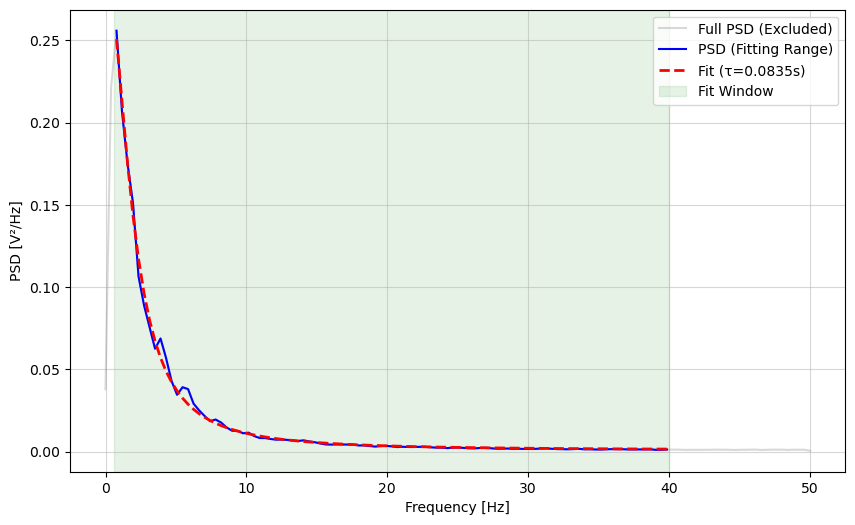

array([0.291915  , 0.08348079, 0.00087632])

In [12]:
fit_lorentzian_psd(freq, psd, 0.6, 40)